# Amazon Product Review Sentiment Analysis using NLP and Machine Learning

## Project Objective
The goal of this project is to analyze Amazon product reviews and classify customer sentiment as positive, neutral, or negative using Natural Language Processing and Machine Learning.

## Project Highlights
- Exploratory Data Analysis on customer reviews
- Text preprocessing and cleaning
- Sentiment scoring using VADER
- Machine Learning models using TF-IDF
- Model comparison between Logistic Regression, Naive Bayes, and Linear SVM
- Final prediction function for custom reviews
- Business insights from customer sentiment patterns

## Inspiration
This project is inspired by sentiment analysis tutorials from Rob Mulla and Simplilearn, but extended with custom EDA, model comparison, evaluation, and business insights.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings

warnings.filterwarnings("ignore")

from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import pickle

In [26]:
nltk.download("stopwords")
nltk.download("vader_lexicon")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import pandas as pd

file_path = "/content/drive/MyDrive/Reviews.csv"

df = pd.read_csv(
    file_path,
    usecols=["Text", "Score", "Summary"],
    nrows=50000
)

df.head()

,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...


In [29]:
df.shape

(50000, 3)

In [30]:
df.rename(columns={
    "Text": "review",
    "Score": "rating",
    "Summary": "summary"
}, inplace=True)

df.head()

,rating,summary,review
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...


In [31]:
df.isnull().sum()

,0
rating,0
summary,2
review,0


In [32]:
df.dropna(inplace=True)
df.drop_duplicates(subset=["review"], inplace=True)

df.shape

(46253, 3)

In [33]:
def create_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(create_sentiment)

df.head()

,rating,summary,review,sentiment
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,positive
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,negative
2,4,"""Delight"" says it all",This is a confection that has been around a fe...,positive
3,2,Cough Medicine,If you are looking for the secret ingredient i...,negative
4,5,Great taffy,Great taffy at a great price. There was a wid...,positive


In [34]:
df["sentiment"].value_counts()


,count
sentiment,
positive,35507
negative,6987
neutral,3759


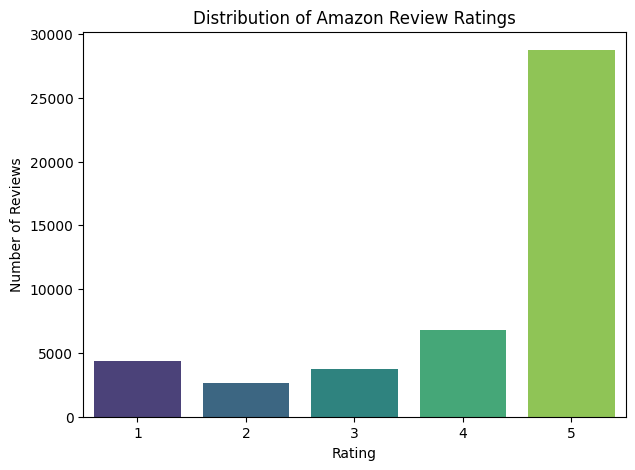

In [35]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="rating", palette="viridis")
plt.title("Distribution of Amazon Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

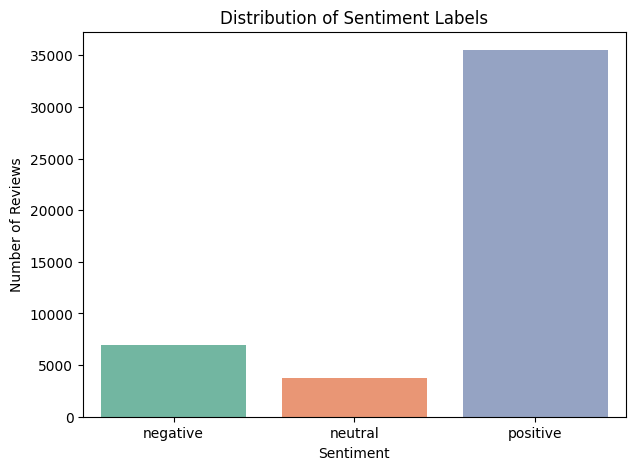

In [36]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x="sentiment",
    order=["negative", "neutral", "positive"],
    palette="Set2"
)
plt.title("Distribution of Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

Reviwe Length Analysis

In [37]:
df["review_length"] = df["review"].apply(lambda x: len(str(x).split()))

df[["review", "review_length", "sentiment"]].head()

,review,review_length,sentiment
0,I have bought several of the Vitality canned d...,48,positive
1,Product arrived labeled as Jumbo Salted Peanut...,31,negative
2,This is a confection that has been around a fe...,94,positive
3,If you are looking for the secret ingredient i...,41,negative
4,Great taffy at a great price. There was a wid...,27,positive


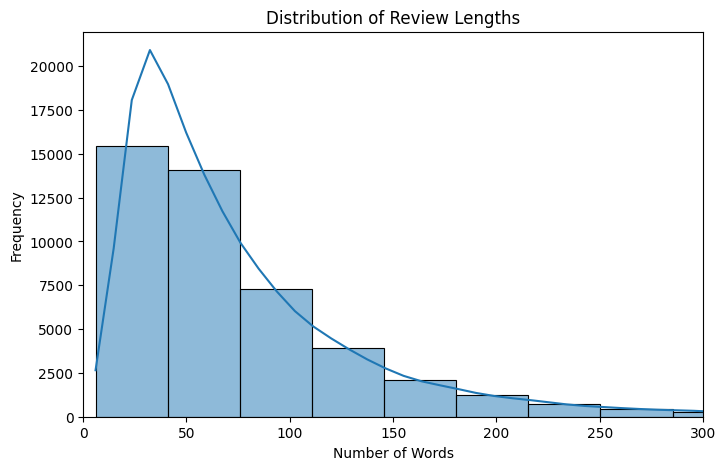

In [38]:
plt.figure(figsize=(8, 5))
sns.histplot(df["review_length"], bins=50, kde=True)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.xlim(0, 300)
plt.show()

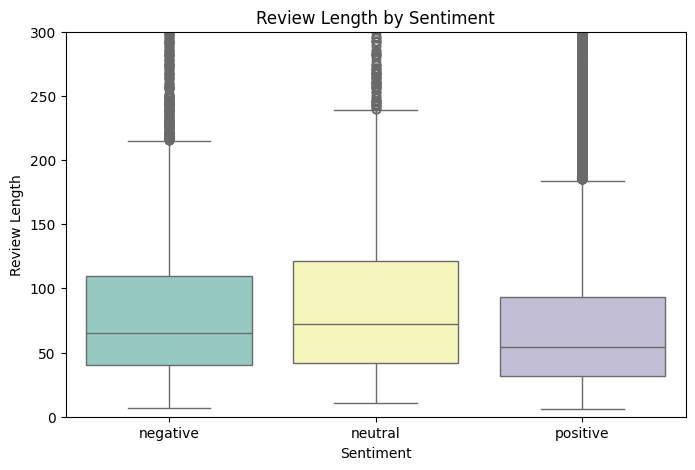

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="sentiment",
    y="review_length",
    order=["negative", "neutral", "positive"],
    palette="Set3"
)
plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length")
plt.ylim(0, 300)
plt.show()

Text Cleaning Setup

In [40]:
import re
import string
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Clean Reviews Text

In [41]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...,positive
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...,negative
2,This is a confection that has been around a fe...,confection around centuries light pillowy citr...,positive
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...,negative
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...,positive


Most Common Words

In [42]:
from collections import Counter

def get_common_words(sentiment, n=20):
    text = " ".join(df[df["sentiment"] == sentiment]["clean_review"])
    words = text.split()
    return Counter(words).most_common(n)

positive_words = get_common_words("positive", 20)
negative_words = get_common_words("negative", 20)
neutral_words = get_common_words("neutral", 20)

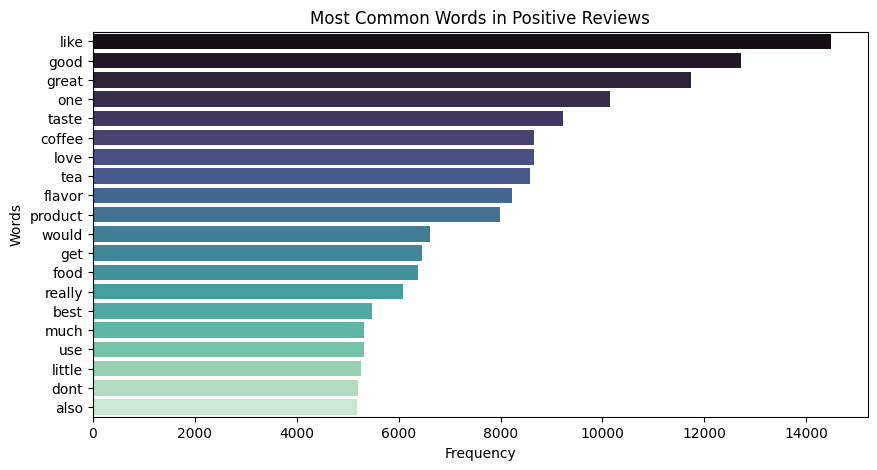

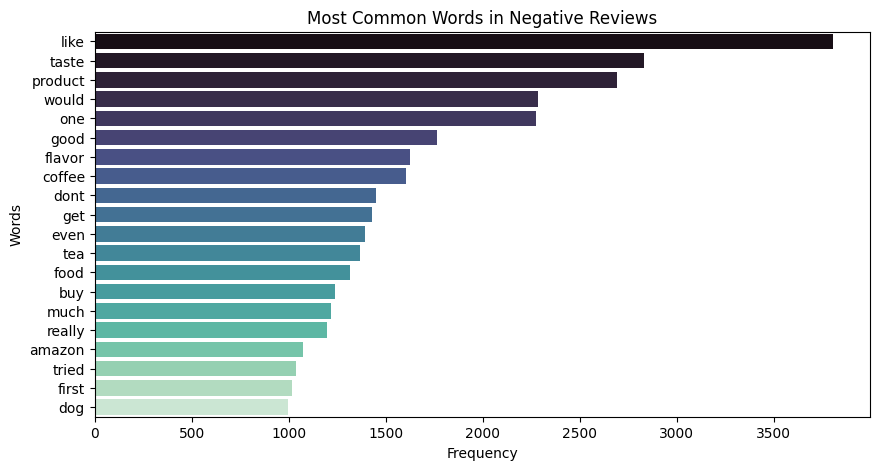

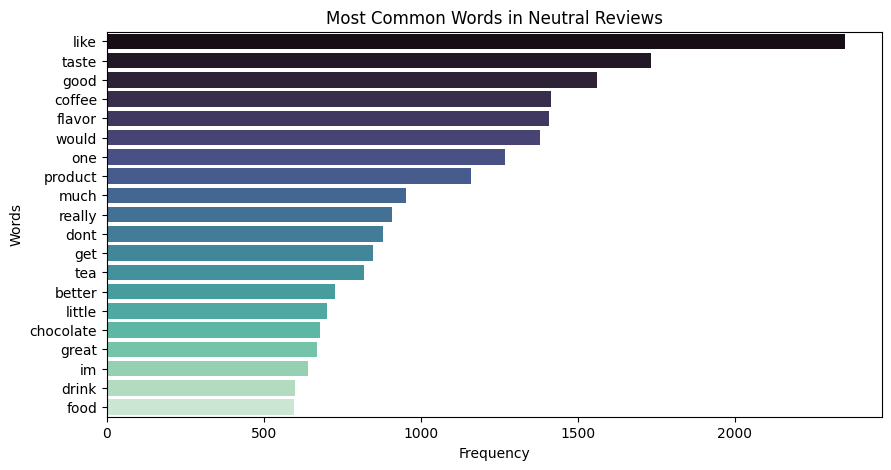

In [43]:
def plot_common_words(common_words, title):
    words = [word[0] for word in common_words]
    counts = [word[1] for word in common_words]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=counts, y=words, palette="mako")
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.show()

plot_common_words(positive_words, "Most Common Words in Positive Reviews")
plot_common_words(negative_words, "Most Common Words in Negative Reviews")
plot_common_words(neutral_words, "Most Common Words in Neutral Reviews")

Preparing Data for ML !!

In [44]:
df_model = df[["clean_review", "sentiment"]].copy()
df_model.dropna(inplace=True)
df_model = df_model[df_model["clean_review"].str.strip() != ""]

df_model.shape

(46253, 2)

In [45]:
df_model["sentiment"].value_counts()

,count
sentiment,
positive,35507
negative,6987
neutral,3759


Training and Testing Split

In [46]:
from sklearn.model_selection import train_test_split

X = df_model["clean_review"]
y = df_model["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

TF-IDF Vectorization

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Train Multiple Models

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(class_weight="balanced")
}

In [49]:
results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    trained_models[model_name] = model

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

    negative       0.63      0.70      0.66      1397
     neutral       0.27      0.51      0.35       752
    positive       0.95      0.84      0.89      7102

    accuracy                           0.79      9251
   macro avg       0.61      0.68      0.63      9251
weighted avg       0.84      0.79      0.81      9251

Naive Bayes
              precision    recall  f1-score   support

    negative       0.84      0.32      0.46      1397
     neutral       0.41      0.02      0.03       752
    positive       0.81      0.99      0.89      7102

    accuracy                           0.81      9251
   macro avg       0.69      0.44      0.46      9251
weighted avg       0.78      0.81      0.76      9251

Linear SVM
              precision    recall  f1-score   support

    negative       0.66      0.66      0.66      1397
     neutral       0.30      0.33      0.31       752
    positive       0.92      0.9

final model comparison

In [50]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,Linear SVM,0.823803,0.829351,0.823803,0.826482
0,Logistic Regression,0.789644,0.844184,0.789644,0.810990
1,Naive Bayes,0.811372,0.783466,0.811372,0.757351


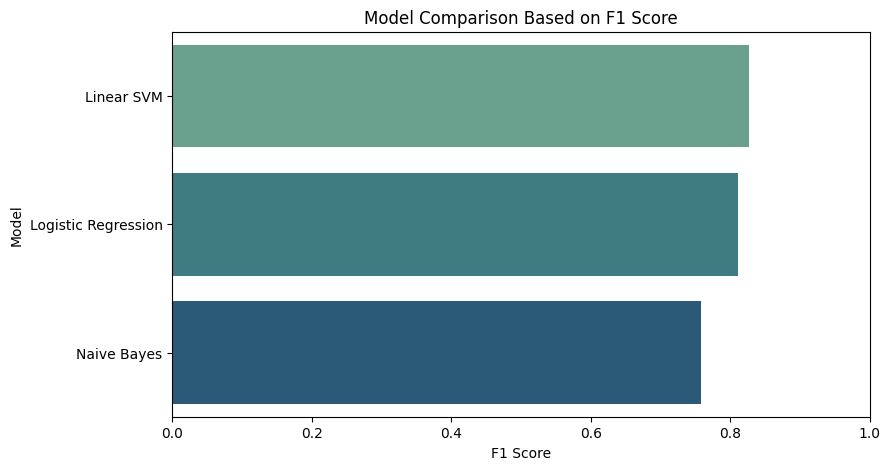

In [51]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="F1 Score", y="Model", palette="crest")
plt.title("Model Comparison Based on F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

Selecting best model

In [73]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Linear SVM


creating confusion matrix

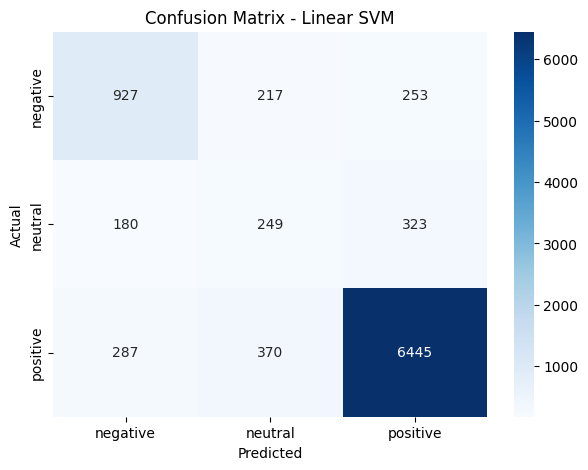

In [53]:
best_pred = best_model.predict(X_test_tfidf)

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=["negative", "neutral", "positive"]
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Custom Prediction Function

In [54]:
def predict_review_sentiment(review):
    cleaned_review = clean_text(review)
    vectorized_review = tfidf.transform([cleaned_review])
    prediction = best_model.predict(vectorized_review)[0]

    return {
        "Review": review,
        "Predicted Sentiment": prediction
    }

In [55]:
predict_review_sentiment("This product is amazing. The quality is excellent and delivery was fast.")

{'Review': 'This product is amazing. The quality is excellent and delivery was fast.',
 'Predicted Sentiment': 'positive'}

In [56]:
predict_review_sentiment("Very bad product. Waste of money and the packaging was terrible.")

{'Review': 'Very bad product. Waste of money and the packaging was terrible.',
 'Predicted Sentiment': 'negative'}

In [57]:
predict_review_sentiment("The product is okay. Not very good, not very bad.")

{'Review': 'The product is okay. Not very good, not very bad.',
 'Predicted Sentiment': 'neutral'}

Saving Model, Vectorization and Result

In [78]:
import pickle

with open("best_sentiment_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

results_df.to_csv("model_comparison_results.csv", index=False)
df.head(1000).to_csv("sample_cleaned_reviews.csv", index=False)

print("Model, vectorizer, and result files saved successfully.")

Model, vectorizer, and result files saved successfully.


Adding VADER Section

In [79]:
import nltk
nltk.download("vader_lexicon")

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


VADER Function

In [65]:
def get_vader_sentiment(text):
    score = sia.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

Applying VADER

In [66]:
df.columns


Index(['rating', 'summary', 'review', 'sentiment', 'review_length',
       'clean_review'],
      dtype='object')

In [67]:
def create_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(create_sentiment)

df[["review", "rating", "sentiment"]].head()

,review,rating,sentiment
0,I have bought several of the Vitality canned d...,5,positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,negative
2,This is a confection that has been around a fe...,4,positive
3,If you are looking for the secret ingredient i...,2,negative
4,Great taffy at a great price. There was a wid...,5,positive


In [68]:
df["vader_sentiment"] = df["review"].apply(get_vader_sentiment)

df[["review", "sentiment", "vader_sentiment"]].head()

,review,sentiment,vader_sentiment
0,I have bought several of the Vitality canned d...,positive,positive
1,Product arrived labeled as Jumbo Salted Peanut...,negative,negative
2,This is a confection that has been around a fe...,positive,positive
3,If you are looking for the secret ingredient i...,negative,neutral
4,Great taffy at a great price. There was a wid...,positive,positive


In [69]:
df.columns

Index(['rating', 'summary', 'review', 'sentiment', 'review_length',
       'clean_review', 'vader_sentiment'],
      dtype='object')

Evaluating VADER

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print(classification_report(df["sentiment"], df["vader_sentiment"]))

vader_accuracy = accuracy_score(df["sentiment"], df["vader_sentiment"])
vader_precision = precision_score(df["sentiment"], df["vader_sentiment"], average="weighted")
vader_recall = recall_score(df["sentiment"], df["vader_sentiment"], average="weighted")
vader_f1 = f1_score(df["sentiment"], df["vader_sentiment"], average="weighted")

print("VADER Accuracy:", vader_accuracy)
print("VADER Precision:", vader_precision)
print("VADER Recall:", vader_recall)
print("VADER F1 Score:", vader_f1)

              precision    recall  f1-score   support

    negative       0.57      0.40      0.47      7535
     neutral       0.15      0.04      0.06      4047
    positive       0.83      0.95      0.89     38418

    accuracy                           0.79     50000
   macro avg       0.52      0.46      0.47     50000
weighted avg       0.74      0.79      0.76     50000

VADER Accuracy: 0.79066
VADER Precision: 0.7375401047352381
VADER Recall: 0.79066
VADER F1 Score: 0.7563149556423827


Adding VADER TO Model Comparison

In [58]:
vader_result = pd.DataFrame([{
    "Model": "VADER",
    "Accuracy": vader_accuracy,
    "Precision": vader_precision,
    "Recall": vader_recall,
    "F1 Score": vader_f1
}])

final_results = pd.concat([results_df, vader_result], ignore_index=True)
final_results = final_results.sort_values(by="F1 Score", ascending=False)

final_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.823803,0.829351,0.823803,0.826482
1,Logistic Regression,0.789644,0.844184,0.789644,0.810990
2,Naive Bayes,0.811372,0.783466,0.811372,0.757351
3,VADER,0.790660,0.737540,0.790660,0.756315


Plotting new comparison

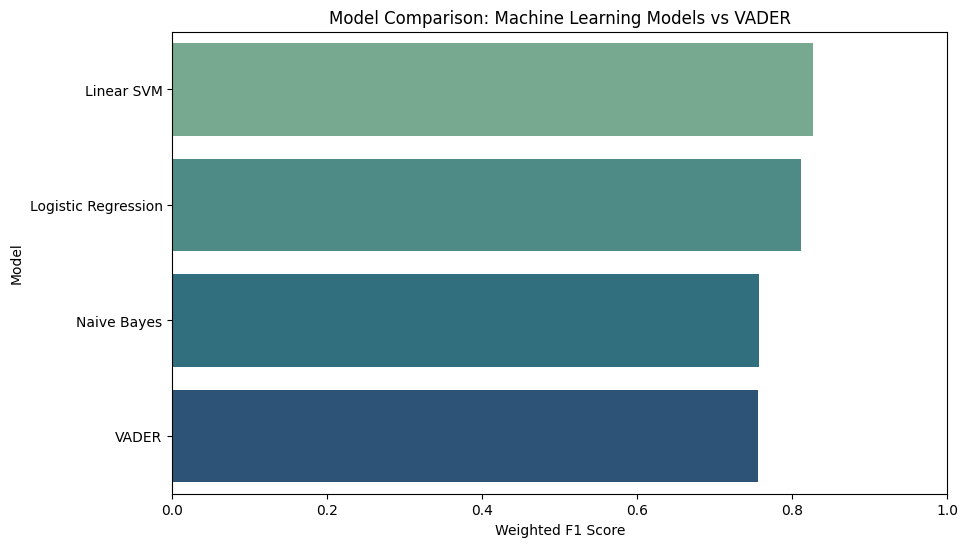

In [59]:
plt.figure(figsize=(10, 6))
sns.barplot(data=final_results, x="F1 Score", y="Model", palette="crest")
plt.title("Model Comparison: Machine Learning Models vs VADER")
plt.xlabel("Weighted F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

VADER Confusion Matrix

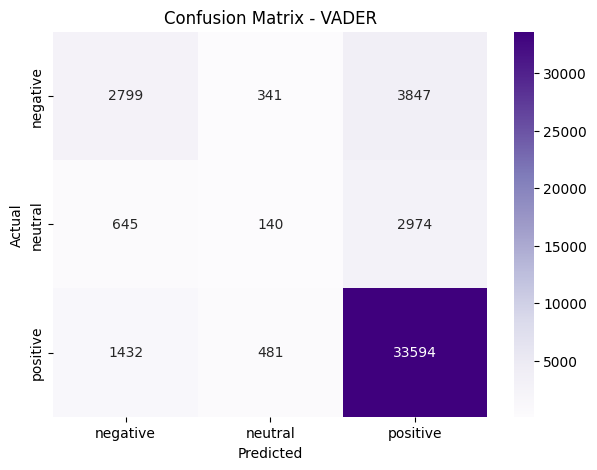

In [70]:
cm_vader = confusion_matrix(
    df["sentiment"],
    df["vader_sentiment"],
    labels=["negative", "neutral", "positive"]
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_vader,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)
plt.title("Confusion Matrix - VADER")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

saving updated result

In [71]:
final_results.to_csv("final_model_comparison_with_vader.csv", index=False)
df.head(1000).to_csv("sample_reviews_with_vader.csv", index=False)

print("Updated VADER results saved successfully.")

Updated VADER results saved successfully.


In [80]:
import pickle
from google.colab import files


with open("best_sentiment_model.pkl", "wb") as file:
    pickle.dump(best_model, file)


with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)


results_df.to_csv("model_comparison_results.csv", index=False)


final_results.to_csv("final_model_comparison_with_vader.csv", index=False)
# 5. Save sample reviews with VADER predictions
df.head(1000).to_csv("sample_reviews_with_vader.csv", index=False)

print("All files saved successfully.")

All files saved successfully.


In [81]:
from google.colab import files

files.download("best_sentiment_model.pkl")
files.download("tfidf_vectorizer.pkl")
files.download("model_comparison_results.csv")
files.download("final_model_comparison_with_vader.csv")
files.download("sample_reviews_with_vader.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion and Business Insights

## Conclusion

This project successfully built an end-to-end sentiment analysis system for Amazon product reviews using Natural Language Processing and Machine Learning.

The project started by loading 50,000 Amazon reviews and converting customer ratings into sentiment labels: positive, neutral, and negative. The review text was cleaned using NLP preprocessing techniques, and TF-IDF vectorization was used to convert text into numerical features.

Multiple machine learning models were trained and evaluated, including Logistic Regression, Naive Bayes, and Linear SVM. In addition to these supervised machine learning models, VADER sentiment analysis was added as a rule-based NLP approach.

The final model comparison showed how traditional machine learning models and VADER perform differently on customer review sentiment classification. Machine learning models learned patterns directly from the dataset, while VADER used predefined sentiment rules and word scores.

Overall, this project demonstrates a complete NLP workflow, including data cleaning, exploratory data analysis, text preprocessing, feature extraction, model training, rule-based sentiment analysis, evaluation, and business insight generation.

## Business Insights

1. Most reviews in the dataset are positive, which suggests that customers are generally satisfied with the reviewed products.

2. Negative reviews are important because they can help businesses identify problems related to product quality, packaging, delivery, or customer expectations.

3. Neutral reviews are harder to classify because they often contain mixed opinions or balanced feedback.

4. VADER is useful for quick sentiment analysis because it does not require training data, but supervised machine learning models can perform better when enough labeled data is available.

5. TF-IDF based machine learning models are effective for identifying important words and patterns in customer reviews.

6. Sentiment analysis can help e-commerce businesses monitor customer satisfaction at scale and understand customer feedback more efficiently.

7. Businesses can use this type of analysis to detect negative feedback early, improve products, and enhance customer experience.

## Final Outcome

The project compares both supervised machine learning and rule-based NLP methods for Amazon review sentiment classification. The best model was selected based on evaluation metrics such as accuracy, precision, recall, and F1-score.

## Future Improvements

- Train the models on the full Amazon review dataset
- Add transformer-based models such as BERT or RoBERTa
- Deploy the sentiment prediction model using Streamlit
- Build a dashboard for business users
- Analyze sentiment by product category or brand